In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import torch
import picard
import random
from glob import glob
from tqdm import tqdm
from pathlib import Path

import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

import boto3
from botocore import UNSIGNED
from botocore.config import Config

d:\Developer\miniproject\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Download Data

In [3]:
# =========================================================
# CONFIGURAÇÕES
# =========================================================

bucket = "physionet-open"
base_prefix = "eegmmidb/1.0.0/"
local_root = "data_eegmmidb"

NUM_PATIENTS = 10
SEED = 42
TOTAL_PATIENTS = 109

# =========================================================
# PREPARAÇÃO
# =========================================================

os.makedirs(local_root, exist_ok=True)

s3 = boto3.client(
    "s3",
    config=Config(signature_version=UNSIGNED)
)

# =========================================================
# SORTEIO REPRODUTÍVEL DOS PACIENTES
# =========================================================

all_patients = [f"S{i:03d}" for i in range(1, TOTAL_PATIENTS + 1)]

random.seed(SEED)
selected_patients = sorted(random.sample(all_patients, NUM_PATIENTS))

print("Pacientes selecionados:")
print(selected_patients)

# =========================================================
# DOWNLOAD DOS PACIENTES SELECIONADOS
# =========================================================

for patient in selected_patients:
    prefix = f"{base_prefix}{patient}/"
    local_dir = os.path.join(local_root, patient)
    os.makedirs(local_dir, exist_ok=True)

    print(f"\n=== Verificando {patient} ===")

    paginator = s3.get_paginator("list_objects_v2")

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            if key.endswith("/"):
                continue

            local_path = os.path.join(
                local_dir,
                os.path.basename(key)
            )

            if os.path.exists(local_path):
                print("Skipping (já existe):", local_path)
                continue

            print("Downloading", key)
            s3.download_file(bucket, key, local_path)

print("\nDownload concluído.")

Pacientes selecionados:
['S004', 'S014', 'S015', 'S018', 'S029', 'S032', 'S036', 'S082', 'S087', 'S095']

=== Verificando S004 ===
Skipping (já existe): data_eegmmidb\S004\S004R01.edf
Skipping (já existe): data_eegmmidb\S004\S004R01.edf.event
Skipping (já existe): data_eegmmidb\S004\S004R02.edf
Skipping (já existe): data_eegmmidb\S004\S004R02.edf.event
Skipping (já existe): data_eegmmidb\S004\S004R03.edf
Skipping (já existe): data_eegmmidb\S004\S004R03.edf.event
Skipping (já existe): data_eegmmidb\S004\S004R04.edf
Skipping (já existe): data_eegmmidb\S004\S004R04.edf.event
Skipping (já existe): data_eegmmidb\S004\S004R05.edf
Skipping (já existe): data_eegmmidb\S004\S004R05.edf.event
Skipping (já existe): data_eegmmidb\S004\S004R06.edf
Skipping (já existe): data_eegmmidb\S004\S004R06.edf.event
Skipping (já existe): data_eegmmidb\S004\S004R07.edf
Skipping (já existe): data_eegmmidb\S004\S004R07.edf.event
Skipping (já existe): data_eegmmidb\S004\S004R08.edf
Skipping (já existe): data_eegmm

In [4]:
# verificando se baixou corretamente
for root, dirs, files in os.walk(local_root):
    print(root, len(files), "arquivos")

data_eegmmidb 0 arquivos
data_eegmmidb\S004 28 arquivos
data_eegmmidb\S014 28 arquivos
data_eegmmidb\S015 28 arquivos
data_eegmmidb\S018 28 arquivos
data_eegmmidb\S029 28 arquivos
data_eegmmidb\S032 28 arquivos
data_eegmmidb\S036 28 arquivos
data_eegmmidb\S082 28 arquivos
data_eegmmidb\S087 28 arquivos
data_eegmmidb\S095 28 arquivos


# Pre-processing

Data pre-processing showing each step and its effects on the signal.

After all data is preprocessed and saved into a file to test it later

In [5]:
# carregando um arquivo .edf
import mne

arquivo = "data_eegmmidb/S004/S004R01.edf"
raw = mne.io.read_raw_edf(
    arquivo,
    preload=True
)

Extracting EDF parameters from data_eegmmidb/S004/S004R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...


Using matplotlib as 2D backend.


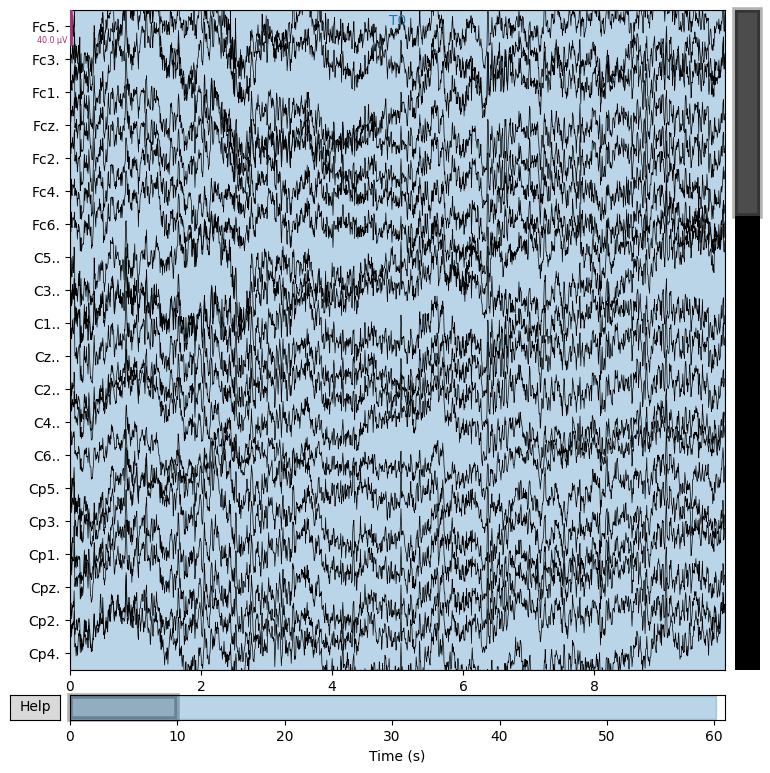

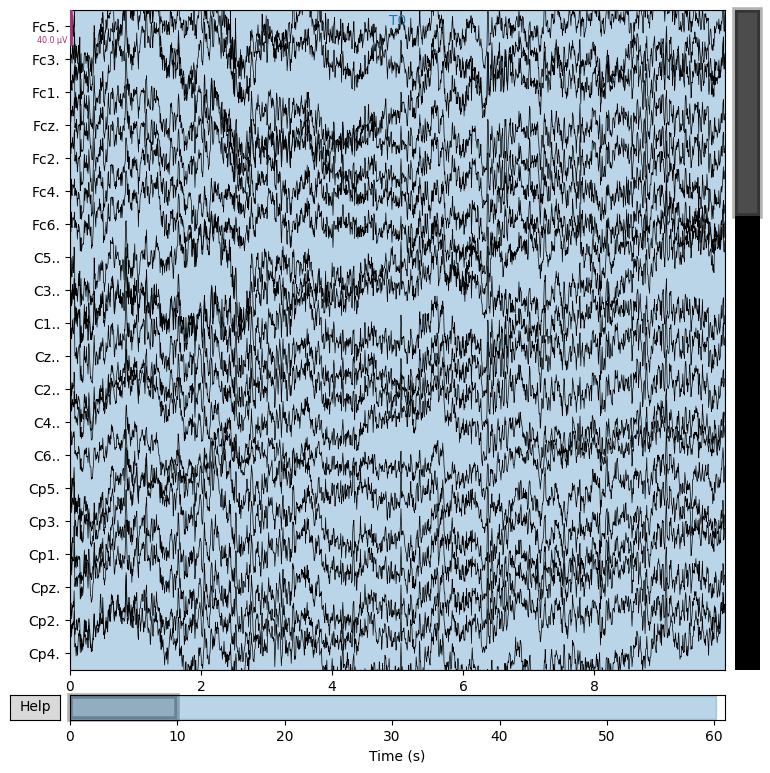

In [6]:
raw.plot()

In [7]:
print(raw.info)
print('Duração (s):', raw.times[-1])
print('Frequência de amostragem:', raw.info['sfreq'])

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Duração (s): 60.99375
Frequência de amostragem: 160.0


In [8]:
files = glob("data_eegmmidb\S*\*.edf")
pattern = re.compile(r'R0*(4|8|12)\.edf$')
filtered = [f for f in files if pattern.search(f)]
len(filtered)

30

In [9]:
def apply_band_filter(raw):
  raw = raw.filter(l_freq=8, h_freq=30, fir_design="firwin", verbose=False)

        # 2. Notch filter 60 Hz
  raw = raw.notch_filter(freqs=60, verbose=False)
  return raw

def apply_ica(raw):
  filt_raw = raw.copy().filter(l_freq=1.0, h_freq=raw.info['sfreq']//2 - 1, verbose=False)
  ica = ICA(15, method='picard', fit_params=dict(ortho=False, extended=True), random_state=42, verbose=False)
  ica.fit(filt_raw)

  ica_labels = label_components(filt_raw, ica, "iclabel")
  exclude = [i for i in range(len(ica_labels["labels"])) if ica_labels["labels"][i] != "brain"]
  
  return ica.apply(raw, exclude, verbose=False)


Extracting EDF parameters from data_eegmmidb\S004\S004R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


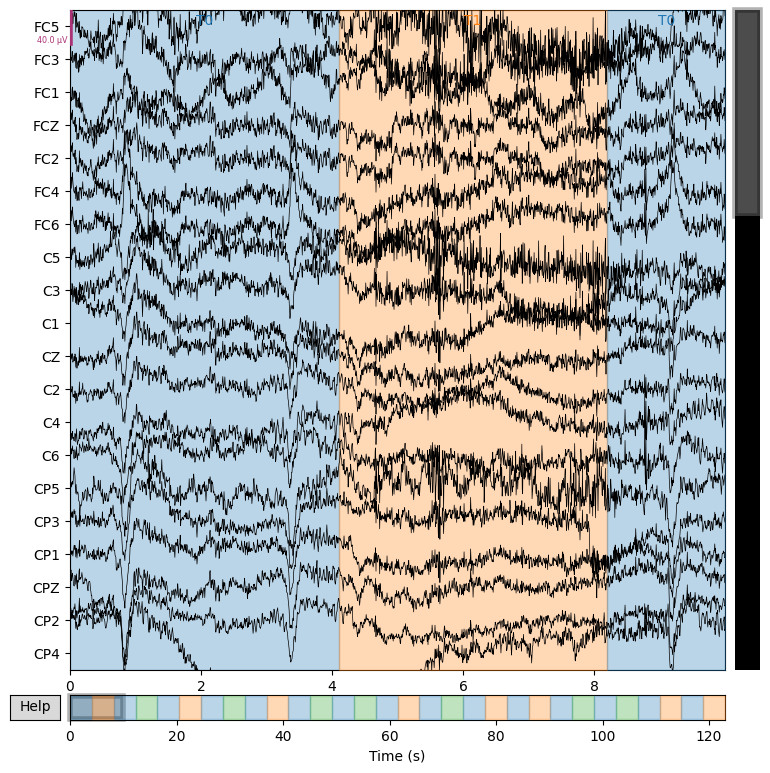

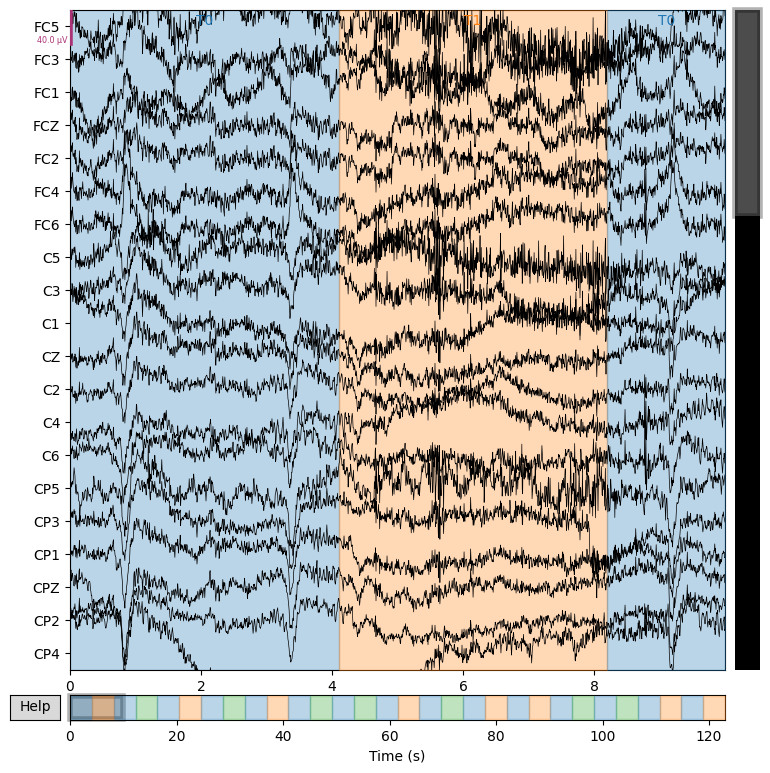

In [10]:
raw = mne.io.read_raw_edf(filtered[0],preload=True)

raw.rename_channels(lambda x: x.strip().replace('.', '').upper())
raw = raw.set_montage("standard_1005", on_missing="warn", match_alias=True, match_case=False)
raw = raw.set_eeg_reference('average')

raw.plot()

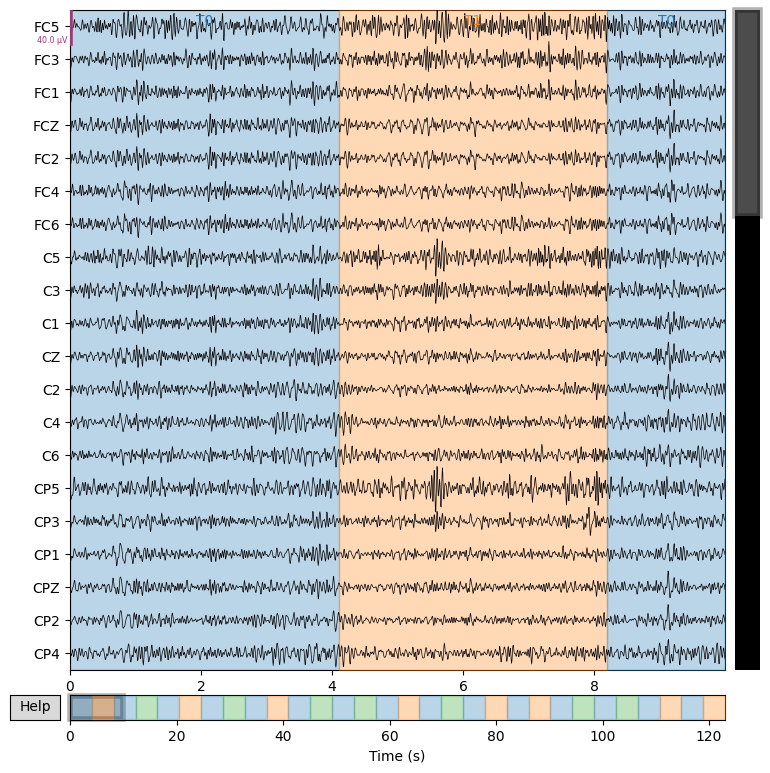

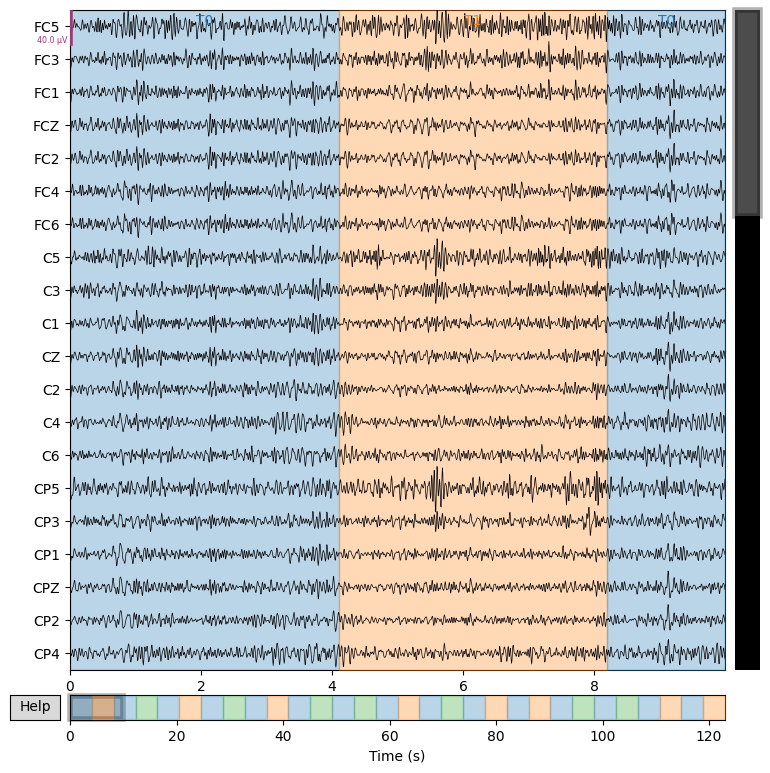

In [11]:
raw = apply_band_filter(raw)
raw.plot()

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 1.5s.


C:\Users\Jose\AppData\Local\Temp\ipykernel_9700\3518952882.py:13: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ica_labels = label_components(filt_raw, ica, "iclabel")


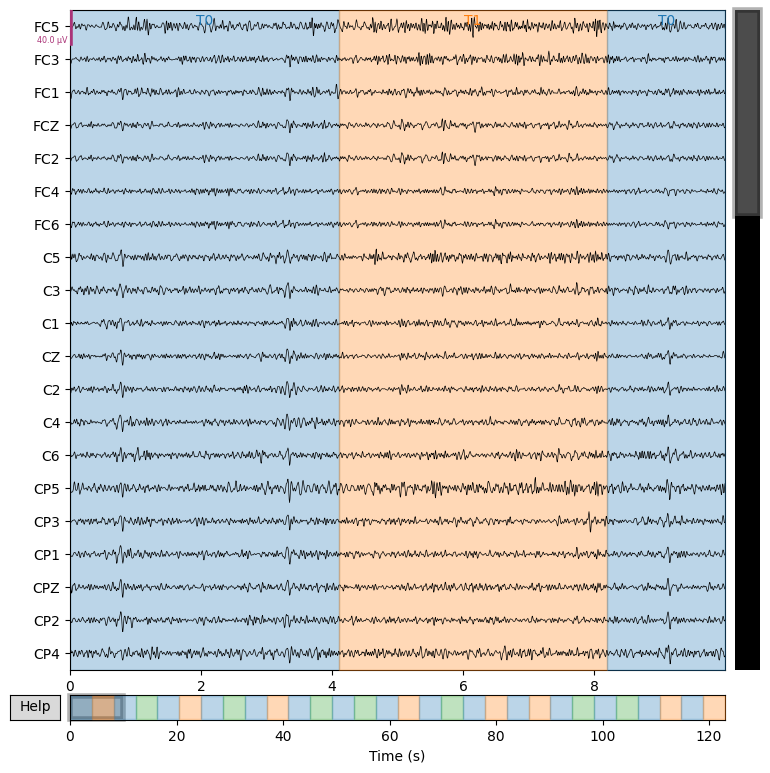

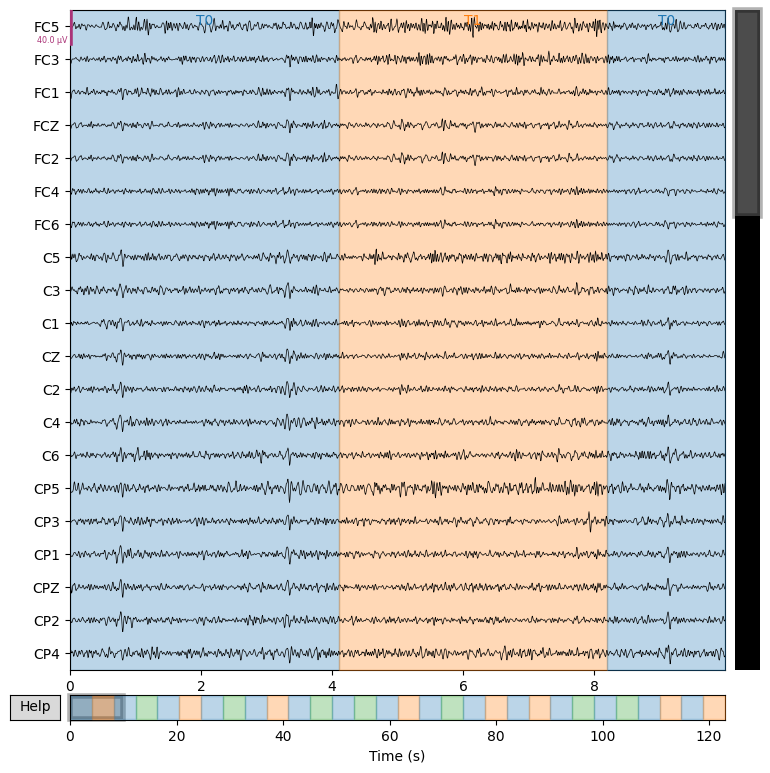

In [12]:
raw = apply_ica(raw)
raw.plot()

In [13]:
def preprocessing(file):
  raw = mne.io.read_raw_edf(file,preload=True)

  raw.rename_channels(lambda x: x.strip().replace('.', '').upper())
  raw = raw.set_montage("standard_1005", on_missing="warn", match_alias=True, match_case=False)
  raw = raw.set_eeg_reference('average')

  raw = apply_band_filter(raw)
  raw = apply_ica(raw)
  return raw

In [14]:
data = preprocessing(filtered[0])

Extracting EDF parameters from data_eegmmidb\S004\S004R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 1.5s.


C:\Users\Jose\AppData\Local\Temp\ipykernel_9700\3518952882.py:13: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ica_labels = label_components(filt_raw, ica, "iclabel")


In [15]:
motor_channels = [
    "C3", "C4", "Cz",
    "FC3", "FC4", "FCz",
    "CP3", "CP4", "CPz"
]

preprocess = False

os.makedirs("preprocessed", exist_ok=True)

for path in tqdm(filtered):
  save_path = os.path.join(
      "preprocessed/",
      path.split("\\")[-1].replace(".edf", "_motor_raw.fif")
  )

  if (not os.path.exists(save_path) or preprocess):
    data = preprocessing(path)
    ch_present = [c for c in motor_channels if c in data.ch_names]
    data = data.pick(ch_present)


    data.save(save_path, overwrite=True)

100%|██████████| 30/30 [00:00<00:00, 7499.65it/s]


## Epochs

Read all the preprocessed data from the files, and separate into epochs.<br> 
10 patients, each with 3 runs, and each run with 15 epochs. (450 input total)

Separate into groups (each group represent all the patient runs)


In [16]:
datas = []
labels = []

for file in os.listdir("preprocessed"):
  raw = mne.io.read_raw_fif("preprocessed\\"+file, preload=False, verbose=False)

  events, event_id = mne.events_from_annotations(
      raw,
      verbose=False
  )

  select_events = {
    "T1": 2,
    "T2": 3
  }

  epochs = mne.Epochs(
      raw,
      events,
      event_id=select_events,
      tmin=0,
      tmax=4,
      baseline=None,
      preload=True,
      reject=None,
      verbose=False
  )

  datas.append(epochs.get_data())
  labels.append(epochs.events[:, 2])

X = np.concatenate(datas, axis=0)
y = np.concatenate(labels, axis=0)

print(X.shape) 
print(y.shape)

(450, 6, 641)
(450,)


In [17]:
X_flat = X.reshape(X.shape[0], -1)

groups = np.repeat(np.arange(len(datas)), [len(x) for x in datas])

logo = LeaveOneGroupOut()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

scores = []
for train_idx, test_idx in tqdm(logo.split(X_flat, y, groups), total=logo.get_n_splits(groups=groups)):
    X_train, X_test = X_flat[train_idx], X_flat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

print(f"Mean accuracy: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")


100%|██████████| 30/30 [00:36<00:00,  1.21s/it]

Mean accuracy: 0.542 (+/- 0.121)


# Model training

In [18]:
def confusion_plot(trues, preds, title):
  cm = confusion_matrix(trues, preds)
  cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

  labels = np.array([[f"{count}\n({pct:.1f}%)" for count, pct in zip(row_c, row_p)]
                    for row_c, row_p in zip(cm, cm_percent)])

  fig, ax = plt.subplots()
  im = ax.imshow(cm_percent, cmap='Blues', vmin=0, vmax=100)
  plt.colorbar(im, ax=ax, label='%')

  ax.set_xticks([0, 1])
  ax.set_xticklabels(['T1', 'T2'])
  ax.set_yticks([0, 1])
  ax.set_yticklabels(['T1', 'T2'])
  ax.set_xlabel('Predicted')
  ax.set_ylabel('True')
  ax.set_title(title)

  for i in range(2):
      for j in range(2):
          ax.text(j, i, labels[i, j], ha='center', va='center',
                  color='white' if cm_percent[i, j] > 50 else 'black')

  disp = ConfusionMatrixDisplay(cm, display_labels=['T1', 'T2'])

  plt.tight_layout()
  plt.show()
  disp.plot(cmap='Blues')
  plt.close()
  return cm

100%|██████████| 30/30 [00:35<00:00,  1.18s/it]


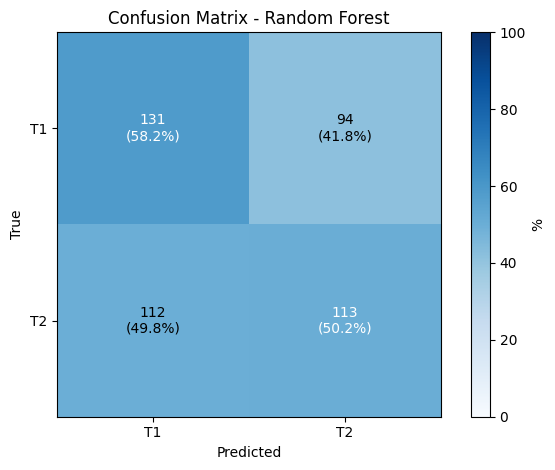

Mean accuracy: 0.542 (+/- 0.121)


In [20]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, warm_start=True, random_state=42)

all_preds = []
all_true = []

for train_idx, test_idx in tqdm(logo.split(X_flat, y, groups), total=logo.get_n_splits(groups=groups)):
    X_train, X_test = X_flat[train_idx], X_flat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf.fit(X_train, y_train)
    all_preds.extend(rf.predict(X_test))
    all_true.extend(y_test)

confusion_plot(all_true, all_preds, "Confusion Matrix - Random Forest")

print(f"Mean accuracy: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")

100%|██████████| 30/30 [00:00<00:00, 36.54it/s]


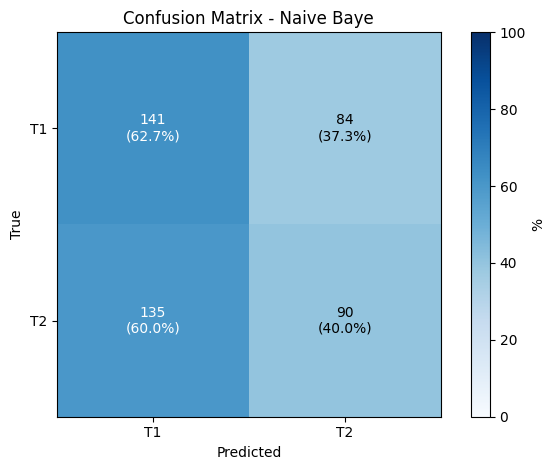

Mean accuracy: 0.513 (+/- 0.071)


In [21]:
gnb = GaussianNB()

all_preds_gnb = []
all_true_gnb = []
scores_gnb = []

for train_idx, test_idx in tqdm(logo.split(X_flat, y, groups), total=logo.get_n_splits(groups=groups)):
    X_train, X_test = X_flat[train_idx], X_flat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    scores_gnb.append(accuracy_score(y_test, y_pred))
    all_preds_gnb.extend(y_pred)
    all_true_gnb.extend(y_test)

confusion_plot(all_true_gnb, all_preds_gnb, "Confusion Matrix - Naive Baye")   

print(f"Mean accuracy: {np.mean(scores_gnb):.3f} (+/- {np.std(scores_gnb):.3f})")

100%|██████████| 30/30 [00:05<00:00,  5.96it/s]


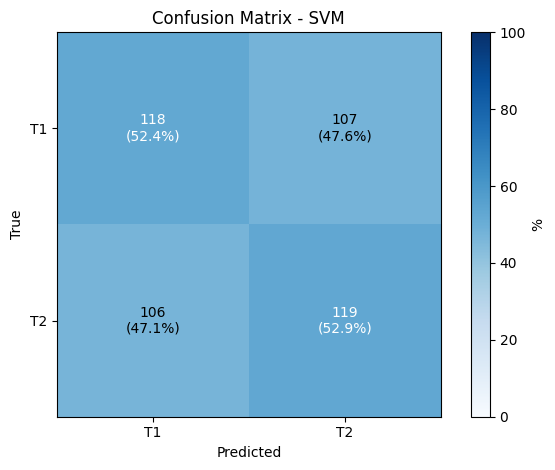

Mean accuracy: 0.527 (+/- 0.111)


In [22]:
svm = SVC()

all_preds_svm = []
all_true_svm = []
scores_svm = []

for train_idx, test_idx in tqdm(logo.split(X_flat, y, groups), total=logo.get_n_splits(groups=groups)):
    X_train, X_test = X_flat[train_idx], X_flat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    scores_svm.append(accuracy_score(y_test, y_pred))
    all_preds_svm.extend(y_pred)
    all_true_svm.extend(y_test)

confusion_plot(all_true_svm, all_preds_svm, "Confusion Matrix - SVM")   

print(f"Mean accuracy: {np.mean(scores_svm):.3f} (+/- {np.std(scores_svm):.3f})")